## Heikin Ashi indicator
Unlike regular candlesticks (which show raw open-high-low-close data for each period), Heikin Ashi candlesticks apply a smoothing formula to make price trends easier to spot.

## Outline
1. Imports and Notebook Configuration
2. Historical Price Data Acquisition
3. Heikin-Ashi Candle Construction
4. Trend & Signal Logic (Bull/Bear Detection)
5. Vectorized Backtest Engine (Entries/Exits)
6. Performance & Risk Metrics Computation
7. Stop-Loss / Take-Profit & Position Sizing
8. Parameter Grid / Random Search Optimization
9. Walk-Forward (Out-of-Sample) Evaluation
10. Visualization: Standard vs Heikin-Ashi with Signals

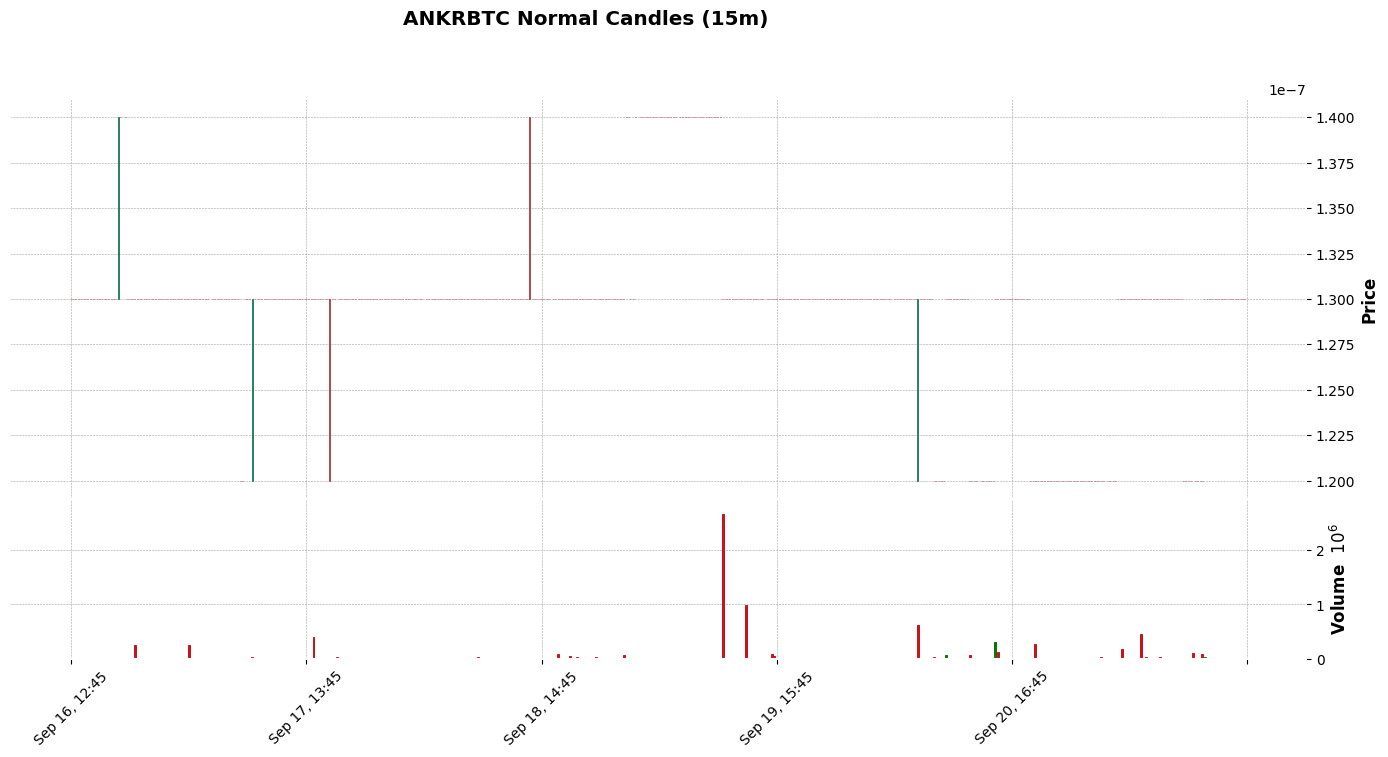

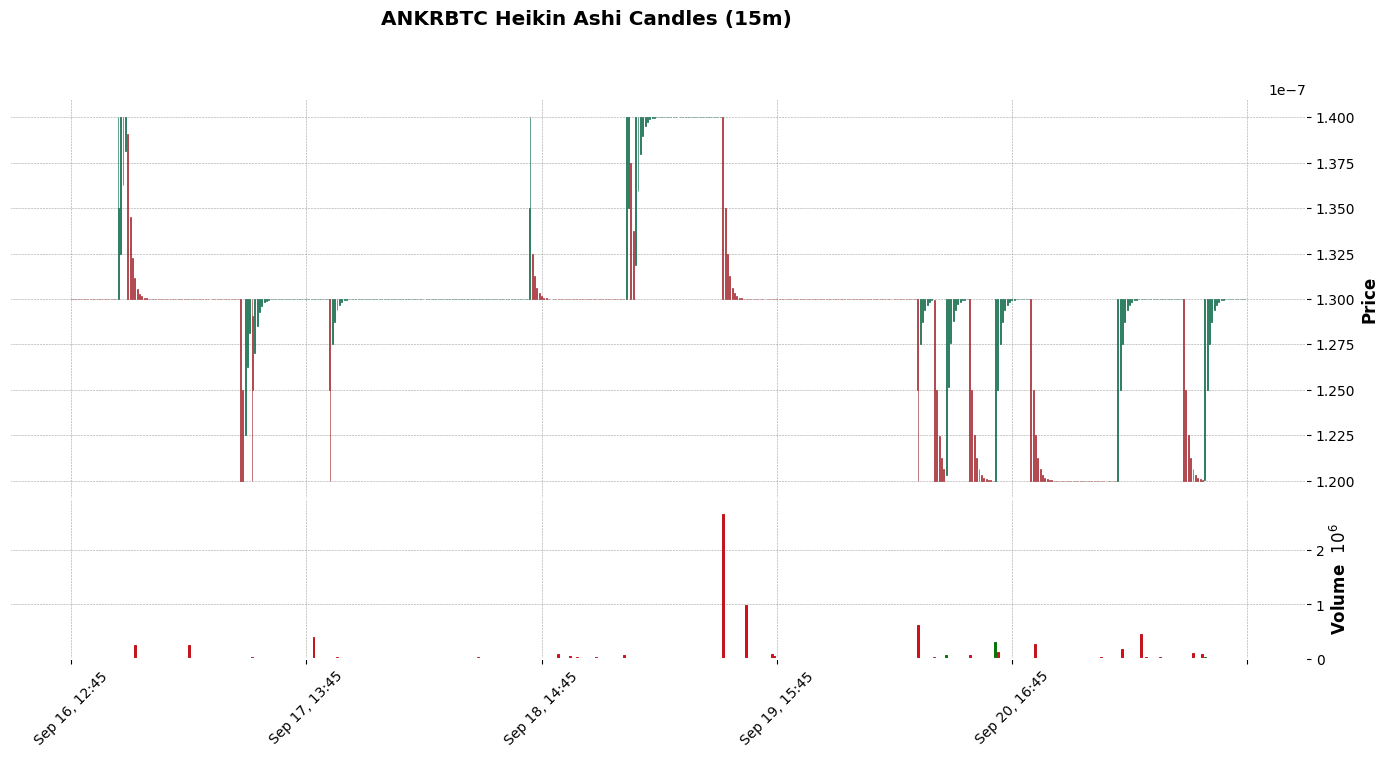

In [5]:
import requests
import pandas as pd
import mplfinance as mpf

# Binance API endpoint for klines (EPICUSDC, 1h)
symbol = "ANKRBTC"
interval = "15m"
limit = 500

url = f"https://api.binance.com/api/v3/klines?symbol={symbol}&interval={interval}&limit={limit}"
response = requests.get(url)
data = response.json()

# Convert to DataFrame
cols = [
    "timestamp",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_asset_volume",
    "trades",
    "taker_base_vol",
    "taker_quote_vol",
    "ignore",
]
df = pd.DataFrame(data, columns=cols)

# Convert numeric columns
for col in ["open", "high", "low", "close", "volume"]:
    df[col] = df[col].astype(float)

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
df.set_index("timestamp", inplace=True)

# -------- Heikin Ashi calculation --------
ha_df = pd.DataFrame(index=df.index, columns=["open", "high", "low", "close"])
ha_df["close"] = (df["open"] + df["high"] + df["low"] + df["close"]) / 4

ha_open = [(df["open"].iloc[0] + df["close"].iloc[0]) / 2]
for i in range(1, len(df)):
    ha_open.append((ha_open[i - 1] + ha_df["close"].iloc[i - 1]) / 2)
ha_df["open"] = ha_open

ha_df["high"] = df[["high"]].join(ha_df[["open", "close"]]).max(axis=1)
ha_df["low"] = df[["low"]].join(ha_df[["open", "close"]]).min(axis=1)

# Prepare both for mplfinance
df_mpf = df[["open", "high", "low", "close", "volume"]]
ha_mpf = ha_df[["open", "high", "low", "close"]].copy()
ha_mpf["volume"] = df["volume"]
ha_df["volume"] = df["volume"]

# Plot
mpf.plot(
    df_mpf,
    type="candle",
    style="charles",
    title=f"{symbol} Normal Candles (15m)",
    volume=True,
    figsize=(18, 8),
)

mpf.plot(
    ha_mpf,
    type="candle",
    style="charles",
    title=f"{symbol} Heikin Ashi Candles (15m)",
    volume=True,
    figsize=(18, 8),
)

## Heikin Ashi Strategy Variants
Three common Heikin Ashi-based strategies: MA filter, wickless candle, and RSI confirmation.

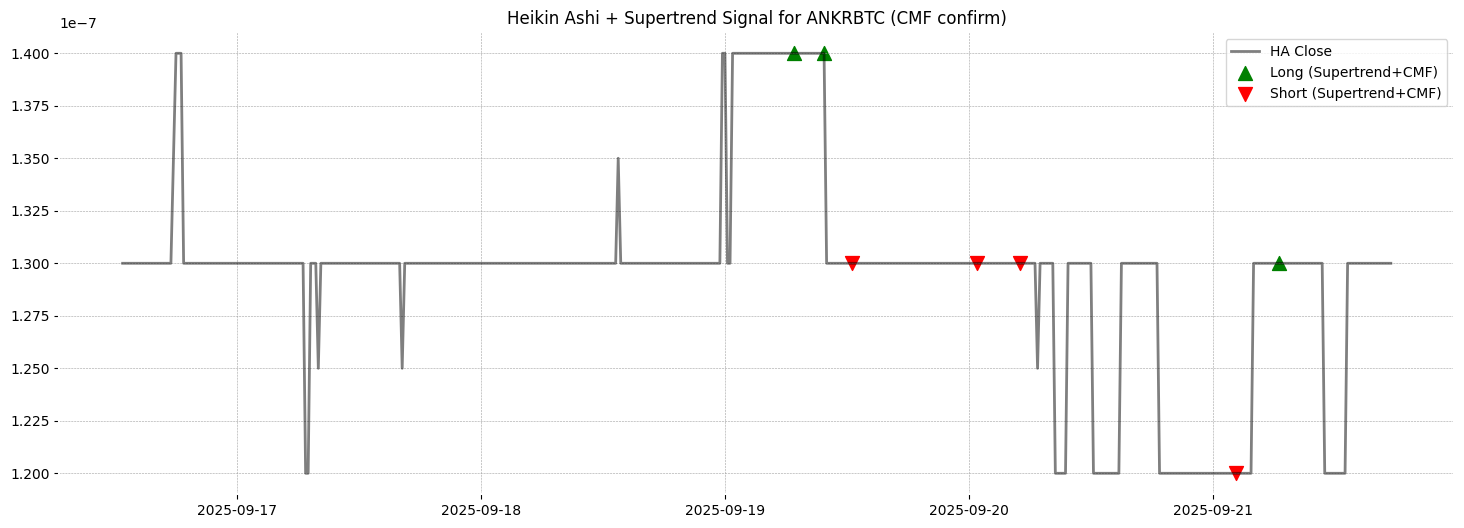

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# --- Chaikin Money Flow (CMF) Calculation ---
def chaikin_money_flow(df, period=20):
    mfv = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / (
        df["high"] - df["low"]
    ).replace(0, np.nan)
    mfv = mfv * df["volume"]
    cmf = (
        mfv.rolling(window=period, min_periods=1).sum()
        / df["volume"].rolling(window=period, min_periods=1).sum()
    )
    return cmf.fillna(0)


# --- Enhanced Supertrend Calculation (ATR-free, long trend focus, very strict) ---
def supertrend(df, period=200, multiplier=10):
    hl2 = (df["high"] + df["low"]) / 2
    price_range = (df["high"] - df["low"]).rolling(window=period, min_periods=1).mean()
    upperband = hl2 + (multiplier * price_range)
    lowerband = hl2 - (multiplier * price_range)
    supertrend = np.zeros(len(df))
    direction = np.ones(len(df))
    for i in range(1, len(df)):
        if df["close"].iloc[i] > upperband.iloc[i - 1]:
            direction[i] = 1
        elif df["close"].iloc[i] < lowerband.iloc[i - 1]:
            direction[i] = -1
        else:
            direction[i] = direction[i - 1]
            if direction[i] == 1 and lowerband.iloc[i] < lowerband.iloc[i - 1]:
                lowerband.iloc[i] = lowerband.iloc[i - 1]
            if direction[i] == -1 and upperband.iloc[i] > upperband.iloc[i - 1]:
                upperband.iloc[i] = upperband.iloc[i - 1]
        supertrend[i] = lowerband.iloc[i] if direction[i] == 1 else upperband.iloc[i]
    df["Supertrend"] = supertrend
    df["Supertrend_Dir"] = direction
    return df


# --- Heikin Ashi + Supertrend Signal with CMF Confirmation ---
def ha_supertrend_signal(
    df,
    supertrend_period=200,
    supertrend_mult=10,
    min_body_pct=0.5,
    trend_confirm=10,
    vol_window=30,
    min_gap=10,
    cmf_period=20,
):
    df = supertrend(df, period=supertrend_period, multiplier=supertrend_mult)
    df["CMF"] = chaikin_money_flow(df, period=cmf_period)
    ha_up = df["close"] > df["open"]
    ha_dn = df["close"] < df["open"]
    # Minimum candle body size filter (as % of range)
    body = np.abs(df["close"] - df["open"])
    rng = (df["high"] - df["low"]).replace(0, np.nan)
    body_pct = body / rng
    body_filter = (body_pct > min_body_pct).fillna(False)
    # Trend confirmation: require Supertrend direction to persist for N bars
    trend_up = (
        pd.Series(df["Supertrend_Dir"])
        .rolling(trend_confirm)
        .apply(lambda x: np.all(x == 1), raw=True)
        == 1
    ).fillna(False)
    trend_dn = (
        pd.Series(df["Supertrend_Dir"])
        .rolling(trend_confirm)
        .apply(lambda x: np.all(x == -1), raw=True)
        == 1
    ).fillna(False)
    # Volume filter: require volume above its moving average
    if "volume" in df.columns:
        vol_ma = df["volume"].rolling(vol_window).mean()
        vol_filter = (df["volume"] > vol_ma).fillna(False)
    else:
        vol_filter = pd.Series([True] * len(df), index=df.index)
    # CMF confirmation: long only if CMF > 0, short only if CMF < 0
    cmf_long = df["CMF"] > 0
    cmf_short = df["CMF"] < 0
    long = (
        ha_up
        & (df["Supertrend_Dir"] == 1)
        & body_filter
        & trend_up
        & vol_filter
        & cmf_long
    )
    short = (
        ha_dn
        & (df["Supertrend_Dir"] == -1)
        & body_filter
        & trend_dn
        & vol_filter
        & cmf_short
    )
    # Enforce minimum gap between signals
    signal = np.zeros(len(df), dtype=int)
    last_signal_idx = -min_gap
    for i in range(len(df)):
        if long.iloc[i] and (i - last_signal_idx >= min_gap):
            signal[i] = 1
            last_signal_idx = i
        elif short.iloc[i] and (i - last_signal_idx >= min_gap):
            signal[i] = -1
            last_signal_idx = i
    return signal


# Apply new signal with CMF confirmation
ha_df["HA_Supertrend_Signal"] = ha_supertrend_signal(
    ha_df,
    supertrend_period=200,
    supertrend_mult=10,
    min_body_pct=0.5,
    trend_confirm=10,
    vol_window=30,
    min_gap=10,
    cmf_period=20,
)

# Plot the new signal
plt.figure(figsize=(18, 6))
plt.plot(ha_df.index, ha_df["close"], label="HA Close", color="black", alpha=0.5)
plt.scatter(
    ha_df.index[ha_df["HA_Supertrend_Signal"] == 1],
    ha_df["close"][ha_df["HA_Supertrend_Signal"] == 1],
    marker="^",
    color="green",
    label="Long (Supertrend+CMF)",
    s=100,
)
plt.scatter(
    ha_df.index[ha_df["HA_Supertrend_Signal"] == -1],
    ha_df["close"][ha_df["HA_Supertrend_Signal"] == -1],
    marker="v",
    color="red",
    label="Short (Supertrend+CMF)",
    s=100,
)
plt.title(f"Heikin Ashi + Supertrend Signal for {symbol} (CMF confirm)")
plt.legend()
plt.show()